<a href="https://colab.research.google.com/github/grkenney/WinSPIRE-HLC-Python/blob/main/Notebooks/Keys/Day_3.2_Line_Graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Line Graphs

Line graphs are often used to show the change in a single variable over time. In this lesson we're going to learn how to make and customize line graphs using `seaborn`.

In [1]:
# import seaborn and nickname it sns
import seaborn as sns

# import pandas and nickname it pd
import pandas as pd

# import matplotlib.pyplot and nickname it plt
import matplotlib.pyplot as plt

# set up inline figures
%matplotlib inline

Next, let's load in our data set.

In [2]:
url = 'https://github.com/grkenney/WinSPIRE-HLC-Python/raw/refs/heads/main/data/qPCR_data_cleaned.csv'
df = pd.read_csv(url)
df.head()

,sample_id,treatment_group,well,timepoint,MKI67,MTOR,BAX,IRF1
0,657317,Control,1,0,1.004377,1.379025,0.799135,0.672194
1,657317,Control,2,8,0.894172,1.345400,0.956142,0.756379
2,657317,Control,3,16,0.679445,1.098444,1.209928,0.050000
3,657317,Control,4,24,0.721341,1.063588,1.586136,0.643022
4,407401,Control,5,0,1.091682,0.843497,0.354864,0.489234


Remember how we wanted to exclude that data point where `MTOR` was > 9. Let's subset our data frame again here before we get into plotting.

In [3]:
# subset df to rows where MTOR < 9
df = df.query("MTOR < 9")

## Expression of one gene

Let's make our first line graph using the `lineplot` function from `seaborn`.

<Axes: xlabel='timepoint', ylabel='BAX'>

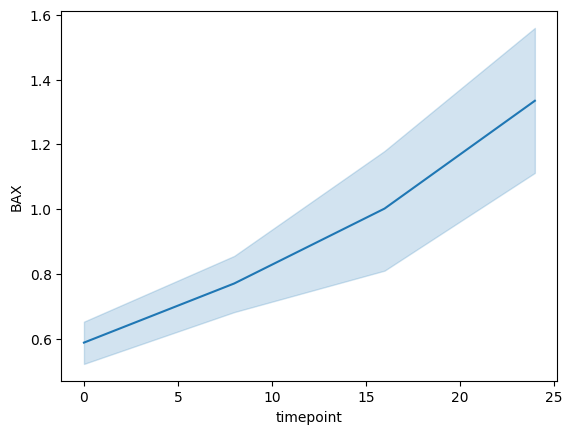

In [4]:
# line graph of BAX signal over time
sns.lineplot(data=df, x="timepoint", y="BAX")

Can you guess why this plot returns both a line and a shaded area?

If we look back at our data, we can see that we have measurements for several samples at each `timepoint`, meaning that each `timepoint` has not just one, but multiple corresponding `BAX` expression values. When this happens, `seaborn` knows to take the **mean** of the data (shown as the single line), but also report the **spread** of the data (here, the *confidence interval*, shown in the shaded band) to give us a sense of how similar/different the expression is across our samples.

But what if we wanted to visualize the *difference* between the expression in the Treatment vs. Control group? `seaborn` lets us do this really simply with the `hue` parameter:

<Axes: xlabel='timepoint', ylabel='BAX'>

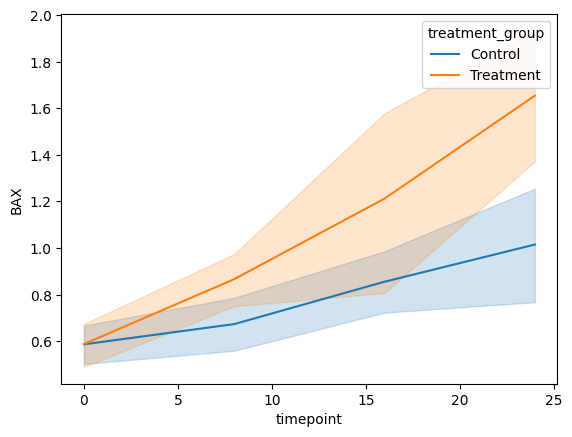

In [5]:
# line graph of BAX signal over time and color by treatment_group
sns.lineplot(data=df, x="timepoint", y="BAX", hue = "treatment_group")

Based on this plot what can we infer about the response of `BAX` to each treatment? By separating the signal in the two treatments we can see that the expression response is not as strong in the Control group (blue) as it is in the Treatment group (blue). 

What if we now wanted to visualize the same separation without using color? We could use another parameter - `style`.

<Axes: xlabel='timepoint', ylabel='BAX'>

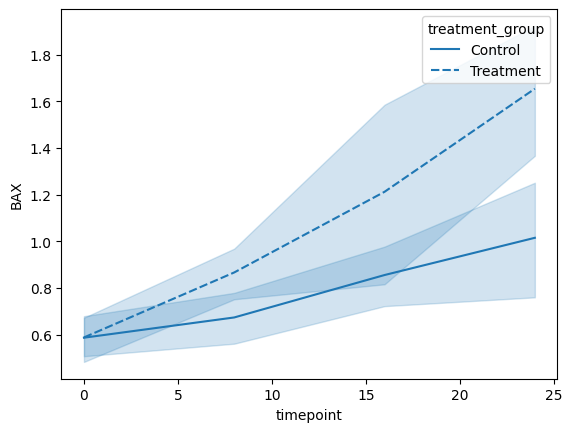

In [6]:
# line graph of BAX signal over time and style by treatment_group
sns.lineplot(data=df, x="timepoint", y="BAX", style = "treatment_group")

**Exercise:** 
1. Plot `IRF1` expression over time with a line graph. *(hint: there should be a single line on this plot)*
3. Change the color of the `IRF1` line graph to your favorite color. *(hint: there should be a single line on this plot)*
4. Separate the line graph of `IRF1` expression by `treatment_group` with both `hue` and `style`. *(hint: there should be two lines on this plot)*
5. Change the colors of the separated line graph using two hexcodes. *(hint: there should be two lines on this plot)*
    * [Hexcode Color Picker](https://htmlcolorcodes.com/color-picker/)

<Axes: xlabel='timepoint', ylabel='IRF1'>

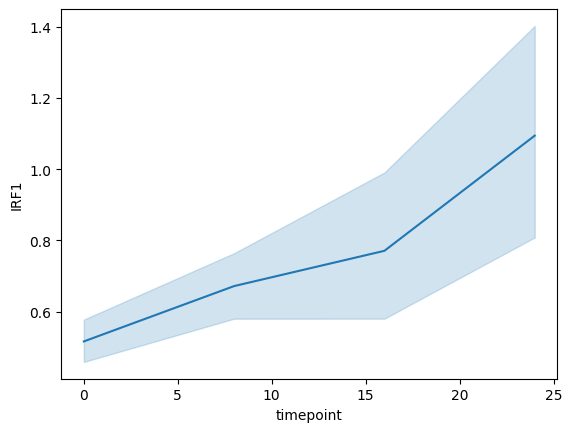

In [7]:
# line graph of IRF1 expression over time
sns.lineplot(data=df, x="timepoint", y="IRF1")

<Axes: xlabel='timepoint', ylabel='IRF1'>

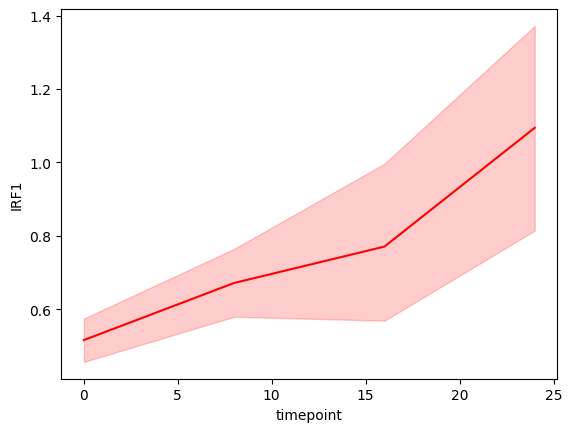

In [8]:
# line graph of IRF1 expression over time in your favorite color
sns.lineplot(data=df, x="timepoint", y="IRF1", color="red")

<Axes: xlabel='timepoint', ylabel='IRF1'>

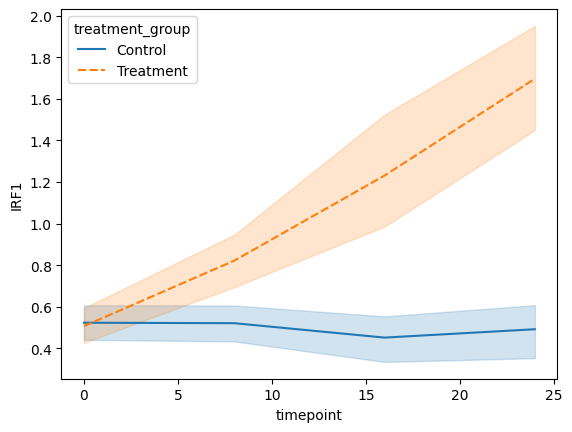

In [9]:
# line graph of IRF1 expression over time separated by treatment_group using both hue and style
sns.lineplot(data=df, x="timepoint", y="IRF1", hue = "treatment_group", style = "treatment_group")

<Axes: xlabel='timepoint', ylabel='IRF1'>

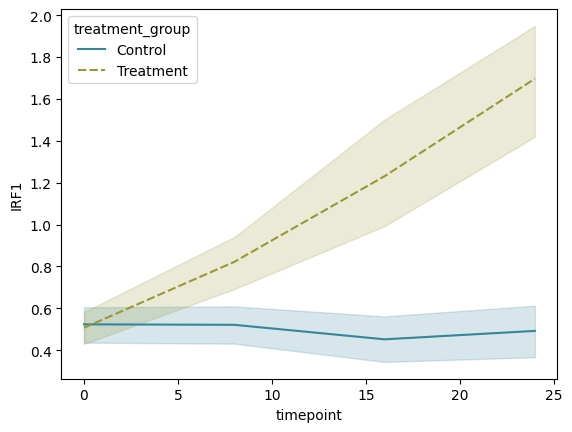

In [10]:
# line graph of IRF1 expression over time separated by treatment_group using both hue and style using hexcode colors
colors = ["#368599", "#979936"]
sns.lineplot(data=df, x="timepoint", y="IRF1", hue = "treatment_group", style = "treatment_group", palette = colors)

## Plot Multiple Genes
Now, let's plot the expression of `BAX` and `MKI67` together. We can do this the same way we did in the previous lesson.

<Axes: xlabel='timepoint', ylabel='BAX'>

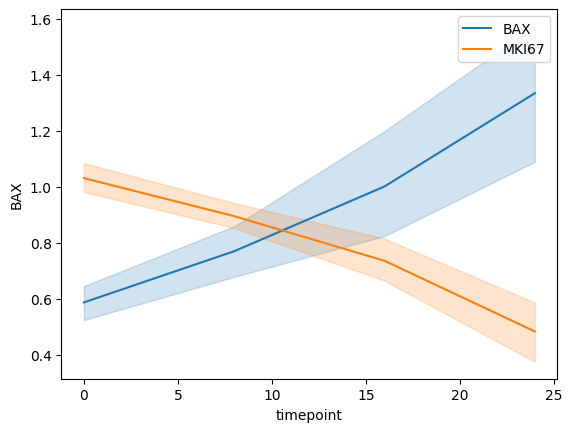

In [11]:
# line graph BAX over time
sns.lineplot(data=df, x="timepoint", y="BAX", label = "BAX")

# line graph of MKI67 over time
sns.lineplot(data=df, x="timepoint", y="MKI67", label = "MKI67")

That worked! We now have two lines, one for each gene.

## More Customization

The plots we've been making so far are great, but we can make them look even better.

First, let's start with plotting `BAX` expression over time, separating `treatment_group` by `style`. We will add each of the following changes one at a time:
* remove the error bars by setting the `errorbar` parameter in `lineplot` to `None`
* add markers to the plot with the `markers` parameter in `lineplot` (a few to try: `o`, `d`, `s`, `X`)

/tmp/gkenney/59388354/c1416ood02.ll.unc.edu/ipykernel_3341810/2179207397.py:2: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=df, x="timepoint", y="BAX",


<Axes: xlabel='timepoint', ylabel='BAX'>

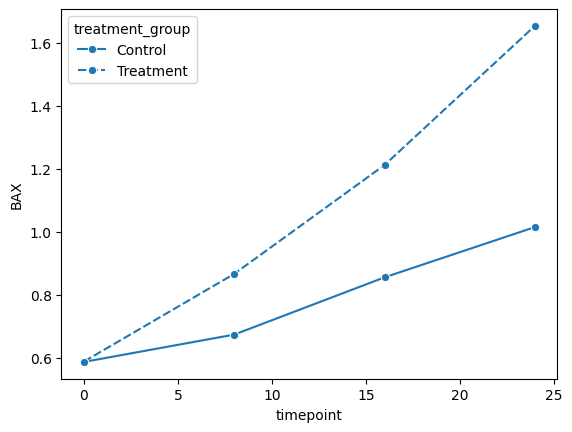

In [12]:
# Plot BAX expression over time separating treatment_group with style
sns.lineplot(data=df, x="timepoint", y="BAX", 
             style = "treatment_group", 
             errorbar=None,
             markers = "o")

Next, let's annotate this plot a little better to communicate what data we are showing.
Let's start with the same plot from above and do the following:
* save the plot to a variable called `bax`
* use the `set_title` method on `bax` to change the title of the plot
* use the `set_xlabel` method on `bax` to change the x-axis label of the plot
* use the `set_ylabel` method on `bax` to change the y-axis label of the plot

/tmp/gkenney/59388354/c1416ood02.ll.unc.edu/ipykernel_3341810/3997480366.py:2: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  bax = sns.lineplot(x="timepoint", y="BAX", data=df,


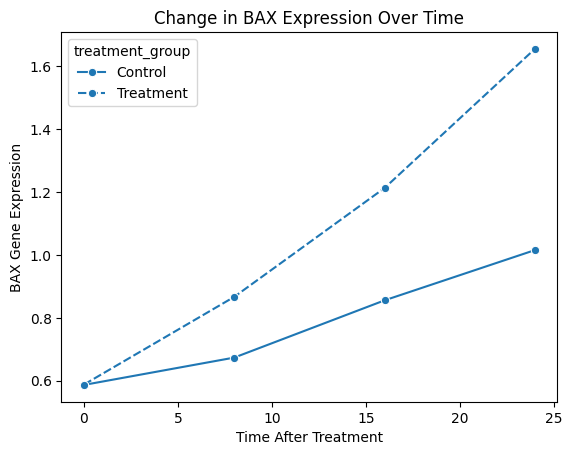

In [13]:
# Plot BAX expression over time separating treatment_group with style
bax = sns.lineplot(x="timepoint", y="BAX", data=df, 
                   style = "treatment_group", errorbar=None,
                   markers = "o")

# Set the title of bax_line to "Change in BAX Expression Over Time"
bax.set_title("Change in BAX Expression Over Time")

# Set the x-axis label to "Time After Treatment"
bax.set_xlabel("Time After Treatment")

# Set the y-axis label to "BAX Gene Expression"
bax.set_ylabel("BAX Gene Expression")

# show the plot
plt.show()

**Exercise:** Try plotting the expression of "MTOR" expression over time with a `lineplot` and make the following customizations:
* Separate by `treatment_group` on both style and color
* Make the Control line any shade of purple and the Treatment line any shade of green
* Remove the error margins
* Mark the data points with your favorite marker
* Add a plot title
* Label the x-axis
* Label the y-axis

/tmp/gkenney/59388354/c1416ood02.ll.unc.edu/ipykernel_3341810/213280588.py:3: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  mtor = sns.lineplot(data=df,


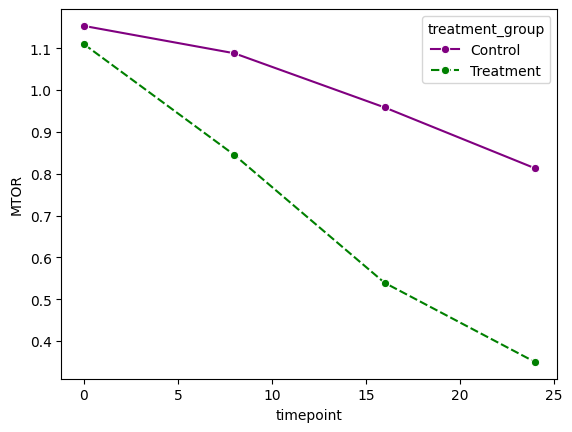

In [14]:
# Plot MTOR expression over time separating treatment_group with style
# and color and save it to a variable mtor
mtor = sns.lineplot(data=df, 
                    x="timepoint", y="MTOR", 
                    style = "treatment_group",
                    hue = "treatment_group", 
                    palette = ["purple", "green"],
                    errorbar=None,
                    markers='o')

# Set the title
bax.set_title("Change in MTOR Expression Over Time")

# Set the x-axis label
bax.set_xlabel("Time After Treatment")

# Set the y-axis label
bax.set_ylabel("MTOR Gene Expression")

# show the plot
plt.show()